# Beginning work of the _substantia nigra_ Brain Atlas project

In [16]:
# Import python modules
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [17]:
# Import dataset
SN_metadata_df = pd.read_excel('../../data/SN_samples_received.xlsx', sheet_name='Samples')
# Drop rows without a sample
SN_metadata_df = SN_metadata_df.dropna(subset='Sample')
# Change the age and PMI to numeric
SN_metadata_df['Age'] = pd.to_numeric(SN_metadata_df['Age'])
SN_metadata_df['PMI'] = pd.to_numeric(SN_metadata_df['PMI'])
SN_metadata_df.tail()

,Sample,Age,Sex,PMI,Case/Control,Neuropath Diagnosis,Clinical Diagnosis,Short Diagnosis,Ethnicity,Race,Sample type,Brain bank,Barcode,Notes,Unnamed: 14,Unnamed: 15
283,34070,78.0,Female,4.250000,NaN,Diagnostic pathology not present,"Unspecified dementia, unspecified severity, wi...",NaN,White,White,pulverized,Mt. Sinai,290398.0,NaN,NaN,NaN
284,Duplicate 84578,86.0,Female,17.833333,Case,Neurocognitive disorder with Lewy bodies,Neurocognitive disorder with Lewy bodies (Conf...,DLB,Black or African-American,Black or African-American,pulverized,Mt. Sinai,182814.0,50mg,NaN,NaN
285,Duplicate 79546,79.0,Male,34.583333,Case,Parkinson's disease,Dementia in other diseases classified elsewher...,PD,Black or African-American,Black or African-American,pulverized,Mt. Sinai,290357.0,NaN,NaN,NaN
286,6209,50.0,Male,NaN,NaN,Alzheimer's disease with early onset,Alzheimer's disease with early onset (Confirme...,NaN,White,NaN,NaN,Mt. Sinai,NaN,NaN,NaN,NaN
287,SP6209,31.0,Male,20.900000,Control,Diagnostic pathology not present,No clinical brain diagnosis found (Investigato...,NaN,NaN,NaN,block,Sepulveda,NaN,NaN,NaN,NaN


In [18]:
# Remove bad samples
SN_metadata_df = SN_metadata_df[~SN_metadata_df['Sample'].isin(['58437', '1468'])]

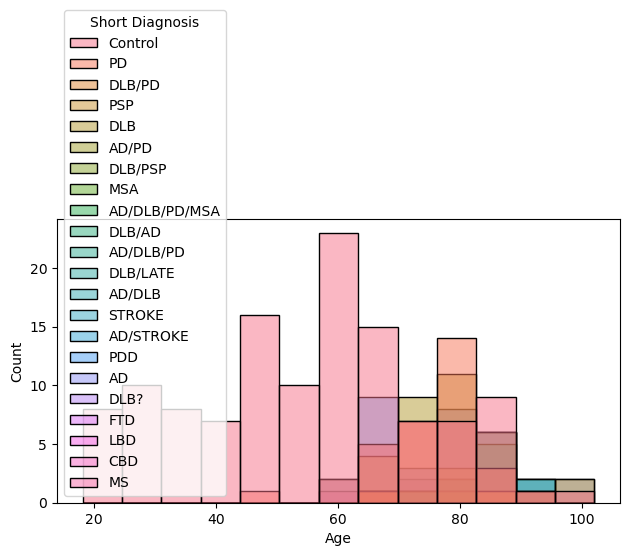

In [5]:
# Count number of male, female
sns.histplot(data=SN_metadata_df, x='Age', hue='Short Diagnosis')
plt.tight_layout()

2


<Axes: xlabel='Sex', ylabel='count'>

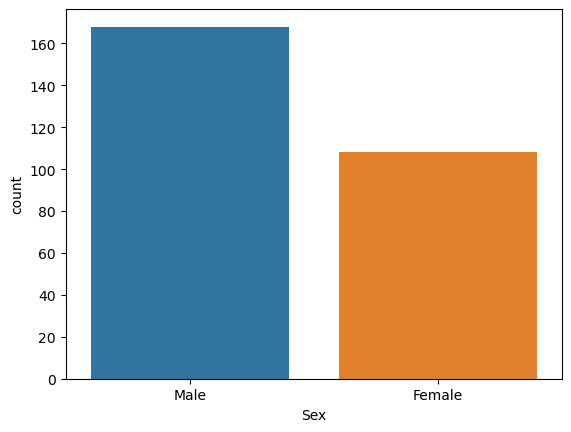

In [6]:
# Count number of male, female
print(len(pd.unique(SN_metadata_df['Sex'])))
sns.countplot(data=SN_metadata_df, x='Sex')

# 

<Axes: xlabel='Sex', ylabel='Age'>

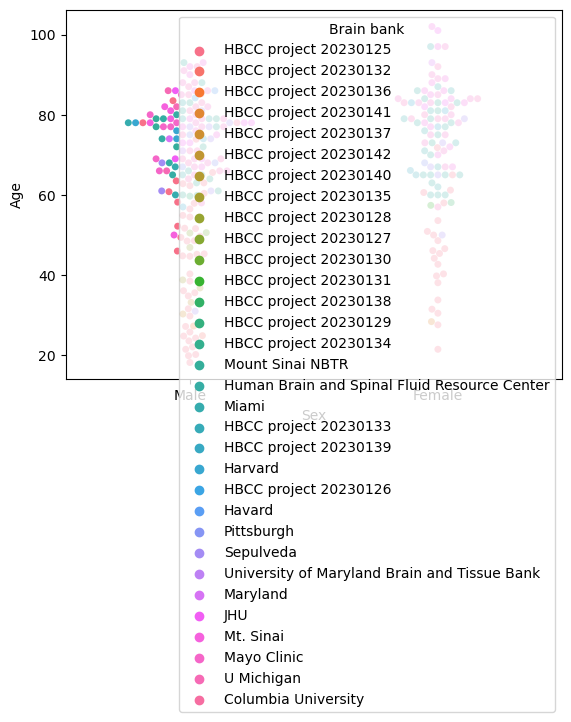

In [7]:
# Breakdown of the gender by age
sns.swarmplot(data=SN_metadata_df, x='Sex', y='Age', hue='Brain bank')

In [20]:
# Add a control or not variable
SN_metadata_df['Control'] = SN_metadata_df['Short Diagnosis'] == 'Control'

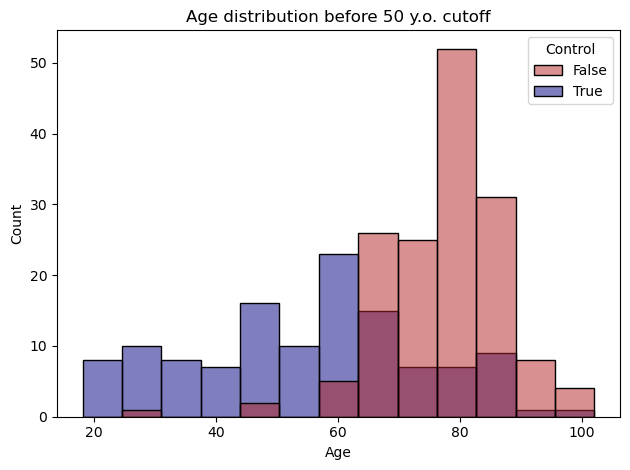

In [21]:
# Replot with Control vs. Diagnosis
sns.histplot(data=SN_metadata_df, x='Age', hue='Control', palette=['firebrick', 'navy'])
plt.title('Age distribution before 50 y.o. cutoff')
plt.tight_layout()

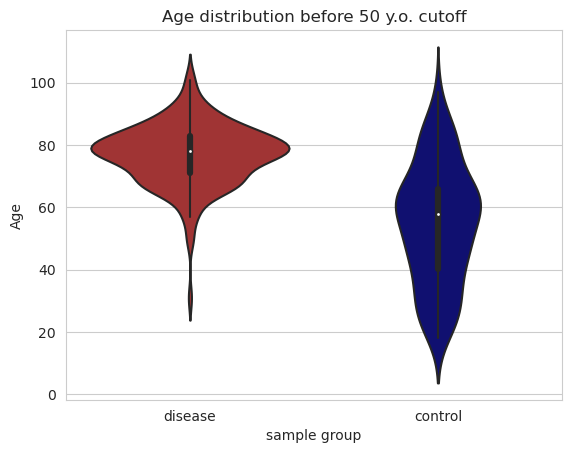

In [22]:
# Replot with Control vs. Diagnosis
with sns.axes_style('whitegrid'):
    sns.violinplot(data=SN_metadata_df, y='Age', x='Control', palette=['firebrick', 'navy'])
    plt.title('Age distribution before 50 y.o. cutoff')
    plt.xticks([0, 1], ['disease', 'control'])
    plt.xlabel('sample group')

In [23]:
# Show the number of samples
print(sum(SN_metadata_df['Control'] ==True), sum(SN_metadata_df['Control'] ==False))

122 154


In [24]:
# Compare the two age distributions
control_df = SN_metadata_df[SN_metadata_df['Control']==True]
disease_df = SN_metadata_df[SN_metadata_df['Control']==False]
#scipy.stats.ttest_ind(control_df['Age'], disease_df['Age'])
scipy.stats.f_oneway(control_df['Age'], disease_df['Age'])

F_onewayResult(statistic=158.62855577430267, pvalue=5.27115268353353e-29)

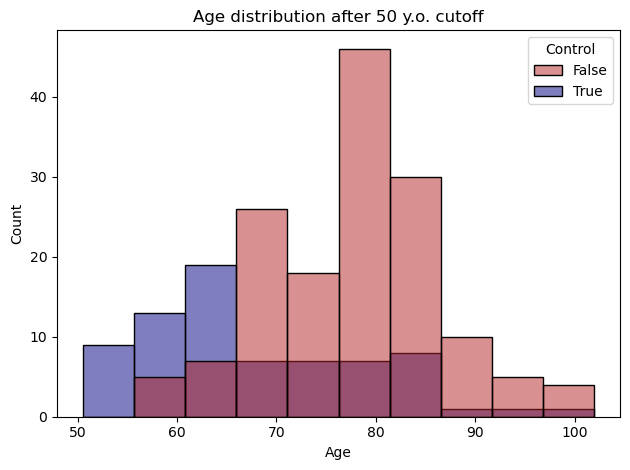

In [25]:
# Remove the ages less than 50 years old
SN_youth_metadata_df = SN_metadata_df[SN_metadata_df['Age'] > 50]
sns.histplot(data=SN_youth_metadata_df, x='Age', hue='Control', palette=['firebrick', 'navy'])
plt.title('Age distribution after 50 y.o. cutoff')
plt.tight_layout()

Text(0.5, 0, 'sample group')

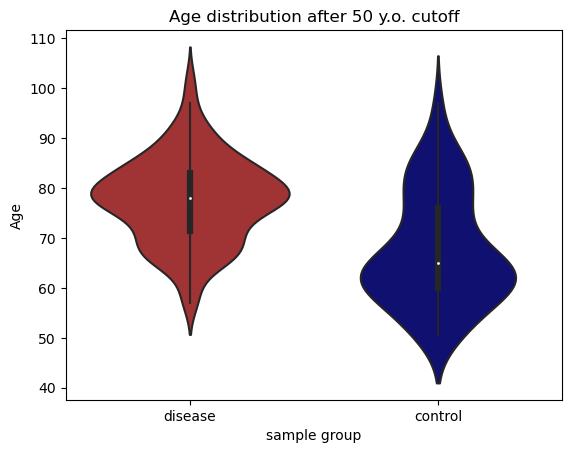

In [26]:
# Replot with Control vs. Diagnosis
sns.violinplot(data=SN_youth_metadata_df, y='Age', x='Control', palette=['firebrick', 'navy'])
plt.title('Age distribution after 50 y.o. cutoff')
plt.xticks([0, 1], ['disease', 'control'])
plt.xlabel('sample group')

In [27]:
# Show the number of samples after the threshold
print(sum(SN_youth_metadata_df['Control'] ==True), sum(SN_youth_metadata_df['Control'] ==False))

73 151


<Axes: xlabel='Sex', ylabel='Age'>

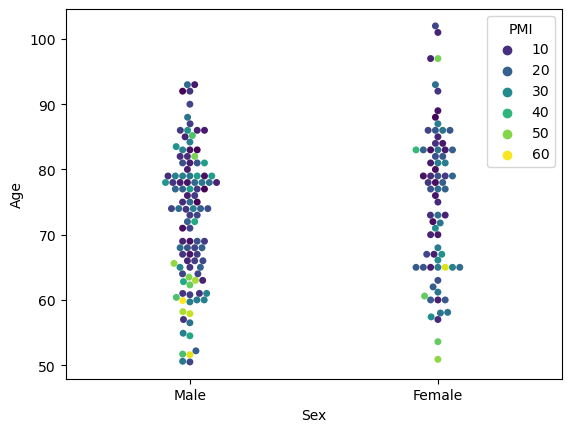

In [28]:
# Breakdown of the gender by age, filtered by age 
sns.swarmplot(data=SN_youth_metadata_df, x='Sex', y='Age', hue='PMI', palette='viridis')

(0.0, 110.0)

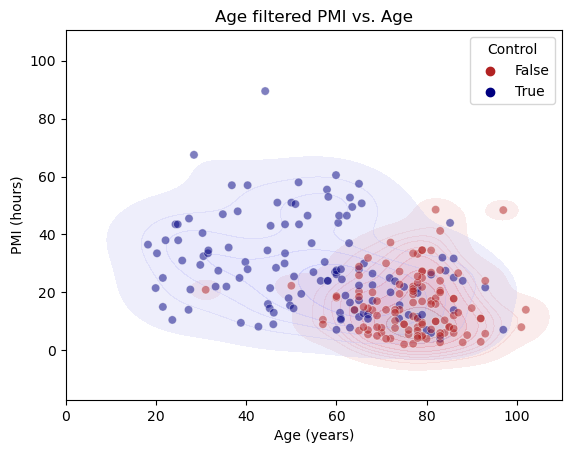

In [29]:
sns.kdeplot(data=SN_metadata_df, x='Age', y='PMI', hue='Control', palette=['firebrick', 'navy'], fill=True, alpha=.25)
sns.scatterplot(data=SN_metadata_df, x='Age', y='PMI', hue='Control', palette=['firebrick', 'navy'], alpha=.5)
plt.title('Age filtered PMI vs. Age')
plt.xlabel('Age (years)')
plt.ylabel('PMI (hours)')
plt.xlim(0,110)

(0.0, 110.0)

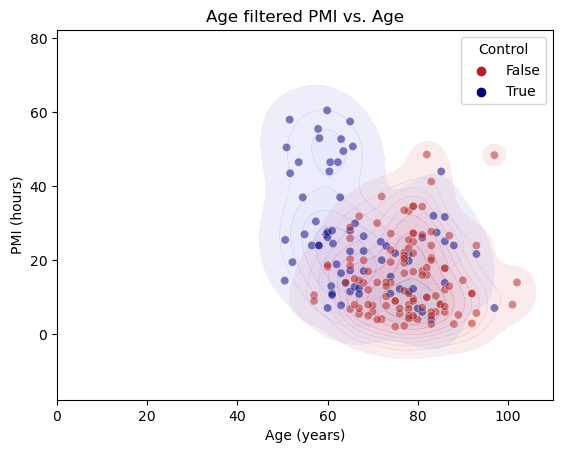

In [31]:
sns.kdeplot(data=SN_youth_metadata_df, x='Age', y='PMI', hue='Control', palette=['firebrick', 'navy'], fill=True, alpha=.25)
sns.scatterplot(data=SN_youth_metadata_df, x='Age', y='PMI', hue='Control', palette=['firebrick', 'navy'], alpha=.5)
plt.title('Age filtered PMI vs. Age')
plt.xlabel('Age (years)')
plt.ylabel('PMI (hours)')
plt.xlim(0,110)
#plt.savefig('../../figure/2024-08-21_age_filtered_pmi_vs_age.png', dpi=300)

In [95]:
# Compare the two age distributions
control_df = SN_youth_metadata_df[SN_youth_metadata_df['Control']==True]
disease_df = SN_youth_metadata_df[SN_youth_metadata_df['Control']==False]
#scipy.stats.ttest_ind(control_df['Age'], disease_df['Age'])
scipy.stats.f_oneway(control_df['Age'], disease_df['Age'])

F_onewayResult(statistic=55.31504229373863, pvalue=2.218228536502219e-12)

In [92]:
# Compare the two PMI distributions
scipy.stats.ttest_ind(control_df['PMI'], disease_df['PMI'])

TtestResult(statistic=nan, pvalue=nan, df=nan)

From these results we see there is a significant difference in the age of the disease vs. control datasets, but the PMI values are not